# Exploration Data Analyse - Instacart Market Basket Analyse

## 1 . Import & chargement des données

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

aisles = pd.read_csv('../data/aisles.csv')
departments = pd.read_csv('../data/departments.csv')
products = pd.read_csv('../data/products.csv')
orders = pd.read_csv('../data/orders.csv')
order_products_prior = pd.read_csv('../data/order_products__prior.csv')
order_products_train = pd.read_csv('../data/order_products__train.csv')

## 2. Dimensions des tables 
Combien de lignes et colonnes par table ? 

In [3]:
datasets = {
    'aisles': aisles,
    'departments': departments,
    'products': products,
    'orders': orders,
    'order_products_prior': order_products_prior,
    'order_products_train': order_products_train
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} lignes, {df.shape[1]} colonnes")

aisles: 134 lignes, 2 colonnes
departments: 21 lignes, 2 colonnes
products: 49688 lignes, 4 colonnes
orders: 3421083 lignes, 7 colonnes
order_products_prior: 32434489 lignes, 4 colonnes
order_products_train: 1384617 lignes, 4 colonnes


## 3. Qualité des données 
pour chaque table : premiere lignes, types de données, valeur manquantes

In [4]:
for name, df in datasets.items():
    print(f" ###---- {name} :")
    print(df.head())
    print(f"\nTypes:\n{df.dtypes}")
    print(f"\nValeurs manquantes:\n{df.isnull().sum()}")

 ###---- aisles :
   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation

Types:
aisle_id     int64
aisle       object
dtype: object

Valeurs manquantes:
aisle_id    0
aisle       0
dtype: int64
 ###---- departments :
   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol

Types:
department_id     int64
department       object
dtype: object

Valeurs manquantes:
department_id    0
department       0
dtype: int64
 ###---- products :
   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robus

## 4. Identification des clés de jointure
Quelles colonnes sont communes entre les tables ? Ça nous permettra de construire le schéma relationnel.

In [5]:
for name, df in datasets.items():
    print(f"{name}: {list(df.columns)}")

aisles: ['aisle_id', 'aisle']
departments: ['department_id', 'department']
products: ['product_id', 'product_name', 'aisle_id', 'department_id']
orders: ['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']
order_products_prior: ['order_id', 'product_id', 'add_to_cart_order', 'reordered']
order_products_train: ['order_id', 'product_id', 'add_to_cart_order', 'reordered']


## 5. Statistiques descriptives

### 5.1 Vue d'ensemble

In [6]:
print(f"Nombre total de commandes : {orders.shape[0]:,}")
print(f"Nombre de clients uniques : {orders['user_id'].nunique():,}")
print(f"Nombre de produits uniques : {products.shape[0]:,}")
print(f"Nombre de rayons : {aisles.shape[0]}")
print(f"Nombre de départements : {departments.shape[0]}")

Nombre total de commandes : 3,421,083
Nombre de clients uniques : 206,209
Nombre de produits uniques : 49,688
Nombre de rayons : 134
Nombre de départements : 21


### 5.2 Combien de produit par commande ? 

In [7]:
products_per_order = order_products_prior.groupby('order_id')['product_id'].count()

print(f"Moyenne : {products_per_order.mean():.1f} produits/commande")
print(f"Médiane : {products_per_order.median():.1f}")
print(f"Min : {products_per_order.min()}")
print(f"Max : {products_per_order.max()}")

Moyenne : 10.1 produits/commande
Médiane : 8.0
Min : 1
Max : 145


### 5.3 Distribution du nombre de produits par commande

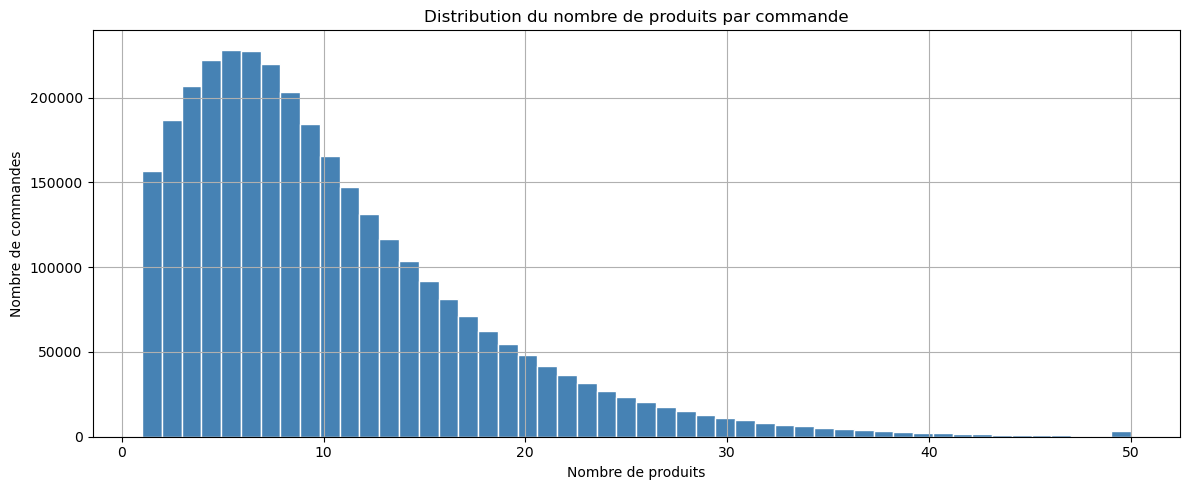

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
products_per_order.clip(upper=50).hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution du nombre de produits par commande')
ax.set_xlabel('Nombre de produits')
ax.set_ylabel('Nombre de commandes')
plt.tight_layout()
plt.savefig('../visual/dist_products_per_order.png', dpi=150)
plt.show()

### 5.4 Top 20 des produits les plus achetés

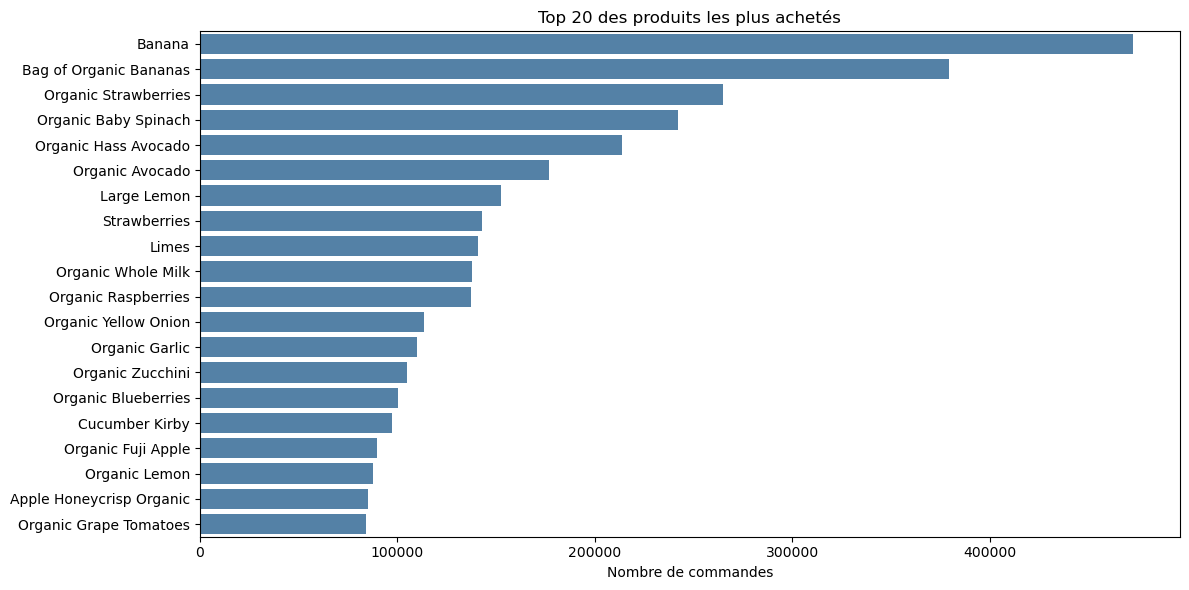

In [9]:
top_products = (
    order_products_prior
    .groupby('product_id')['order_id']
    .count()
    .reset_index(name='nb_orders')
    .merge(products, on='product_id')
    .sort_values('nb_orders', ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_products, x='nb_orders', y='product_name', color='steelblue', ax=ax)
ax.set_title('Top 20 des produits les plus achetés')
ax.set_xlabel('Nombre de commandes')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../visual/top20_products.png', dpi=150)
plt.show()

### 5.5 Quand les clients commandent-ils ?
Distribution par jour de la semaine et par heure.

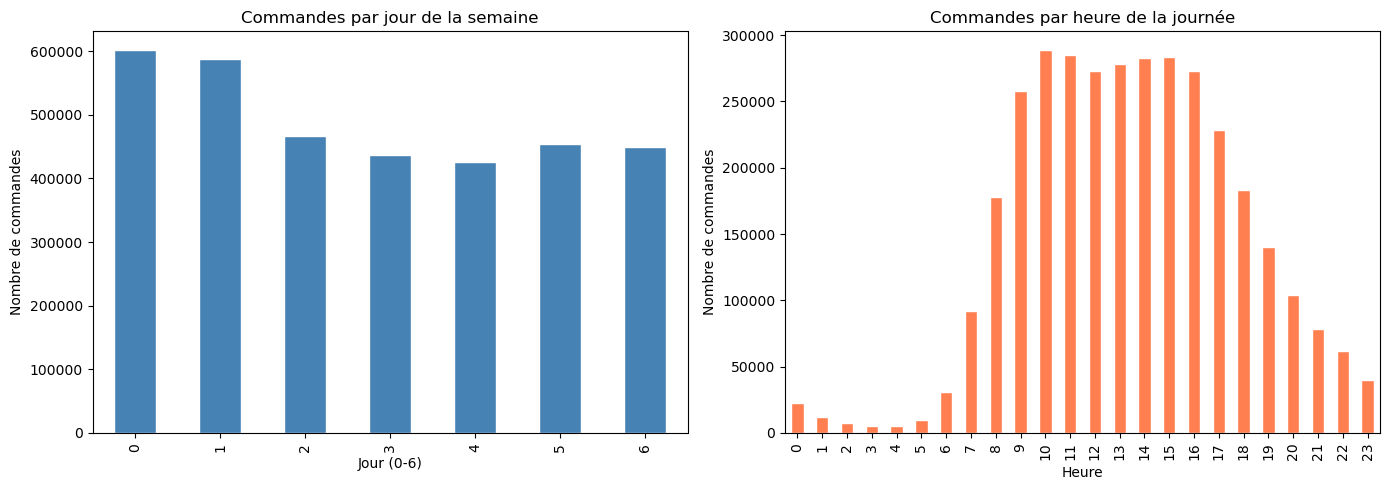

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Par jour (0=lundi ou dimanche selon le dataset)
orders['order_dow'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Commandes par jour de la semaine')
axes[0].set_xlabel('Jour (0-6)')
axes[0].set_ylabel('Nombre de commandes')

# Par heure
orders['order_hour_of_day'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Commandes par heure de la journée')
axes[1].set_xlabel('Heure')
axes[1].set_ylabel('Nombre de commandes')

plt.tight_layout()
plt.savefig('../visual/orders_time_distribution.png', dpi=150)
plt.show()

### 5.6 Taux de réachat (reorder)
Quelle proportion des produits ajoutés au panier sont des réachats ?

In [11]:
reorder_rate = order_products_prior['reordered'].mean() * 100
print(f"Taux de réachat global : {reorder_rate:.1f}%")

# Top 10 produits les plus réachetés (parmi ceux avec assez de commandes)
reorder_by_product = (
    order_products_prior
    .groupby('product_id')
    .agg(nb_orders=('order_id', 'count'), reorder_rate=('reordered', 'mean'))
    .query('nb_orders >= 1000')
    .sort_values('reorder_rate', ascending=False)
    .head(10)
    .merge(products, on='product_id')
)

print("\nTop 10 produits avec le plus haut taux de réachat (min 1000 commandes) :")
print(reorder_by_product[['product_name', 'nb_orders', 'reorder_rate']].to_string(index=False))

Taux de réachat global : 59.0%

Top 10 produits avec le plus haut taux de réachat (min 1000 commandes) :
                   product_name  nb_orders  reorder_rate
Half And Half Ultra Pasteurized       2921      0.861691
     Whole Organic Omega 3 Milk       9108      0.860233
Organic Lactose Free Whole Milk       8477      0.859030
 Organic Homogenized Whole Milk       3970      0.857683
           Ultra-Purified Water       1489      0.857623
       Milk, Organic, Vitamin D      20198      0.854342
       Organic Reduced Fat Milk      35663      0.850686
                      Goat Milk       5185      0.849952
                         Banana     472565      0.843501
            Organic  Whole Milk       9842      0.841191


## 6. Nettoyage & Préparation des données

### 6.1 Fusion des tables
On crée une table unique qui relie chaque commande à ses produits avec leurs noms.

In [12]:
# On travaille avec prior (le plus gros jeu, plus représentatif)
df = (
    order_products_prior
    .merge(products, on='product_id')
    .merge(aisles, on='aisle_id')
    .merge(departments, on='department_id')
    .merge(orders, on='order_id')
)

print(f"Table fusionnée : {df.shape[0]:,} lignes, {df.shape[1]} colonnes")
print(f"\nColonnes : {list(df.columns)}")
df.head()


Table fusionnée : 32,434,489 lignes, 15 colonnes

Colonnes : ['order_id', 'product_id', 'add_to_cart_order', 'reordered', 'product_name', 'aisle_id', 'department_id', 'aisle', 'department', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']


,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs,202279,prior,3,5,9,8.0
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce,202279,prior,3,5,9,8.0
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry,202279,prior,3,5,9,8.0
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry,202279,prior,3,5,9,8.0
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry,202279,prior,3,5,9,8.0


### 6.2 Vérification post-fusion
On vérifie qu'il n'y a pas eu de perte ou duplication lors des jointures.

In [13]:
print(f"Lignes avant fusion (order_products_prior) : {order_products_prior.shape[0]:,}")
print(f"Lignes après fusion : {df.shape[0]:,}")
print(f"Différence : {df.shape[0] - order_products_prior.shape[0]:,}")
print(f"\nValeurs manquantes après fusion :")
print(df.isnull().sum()[df.isnull().sum() > 0])

Lignes avant fusion (order_products_prior) : 32,434,489
Lignes après fusion : 32,434,489
Différence : 0

Valeurs manquantes après fusion :
days_since_prior_order    2078068
dtype: int64


### 6.3 Échantillonnage
32M de lignes c'est trop lourd pour Apriori. On va échantillonner un sous-ensemble de clients pour garder des paniers complets.

In [14]:
# On prend 10 000 clients aléatoires (paniers complets conservés)
import numpy as np

np.random.seed(42)
sample_users = np.random.choice(df['user_id'].unique(), size=10000, replace=False)
df_sample = df[df['user_id'].isin(sample_users)]

print(f"Clients échantillonnés : {df_sample['user_id'].nunique():,}")
print(f"Commandes : {df_sample['order_id'].nunique():,}")
print(f"Lignes : {df_sample.shape[0]:,}")
print(f"Produits uniques : {df_sample['product_id'].nunique():,}")

Clients échantillonnés : 10,000
Commandes : 154,792
Lignes : 1,543,809
Produits uniques : 35,081


### 6.4 Sauvegarde du dataset nettoyé
On sauvegarde pour ne pas refaire la fusion à chaque fois.

In [15]:
df_sample.to_csv('../data/instacart_sample_clean.csv', index=False)
print("Dataset sauvegardé !")

Dataset sauvegardé !
